<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-JeremyDail/blob/main/RK2Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Projectile Motion with Linear Drag using second-order Runge-Kutta. RK2 is used to simulate motion of a projectile under gravity's influence with linear drag.

#Drag is: F_drag = -b v
#Equations of motion will be: dx/dt = vx, dy/dt = vy, dvx/dt = -(b/m) vx, and dvy/dt = =g = (b/m) vy

#Hopefully, the simulation will stop when the projectile hits the ground.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
m = 1.0
b = 0.1

x0, y0 = 0.0, 0.0
v0 = 20.0
theta = np.deg2rad(45)

vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

dt = 0.01
tmax = 10

In [13]:
def derivatives (t, state):
  x , y, vx, vy = state

  ax = -(b/m) * vx
  ay = -g - (b/m) * vy

  return np.array([vx, vy, ax, ay])


In [14]:
def rk2_step(f, t, state, dt):
  k1 = f(t, state)
  k2 = f(t + dt, state + dt/2 * k1)
  return state + dt * k2

In [15]:
state = np.array([x0, y0, vx0, vy0])
t = 0

t_values = [t]
x_values = [state[0]]
y_values = [state[1]]

while t < tmax:
  state = rk2_step(derivatives, t, state, dt)
  t += dt

  t_values.append(t)
  x_values.append(state[0])
  y_values.append(state[1])

  if state[1] < 0 and t > 0:
    break


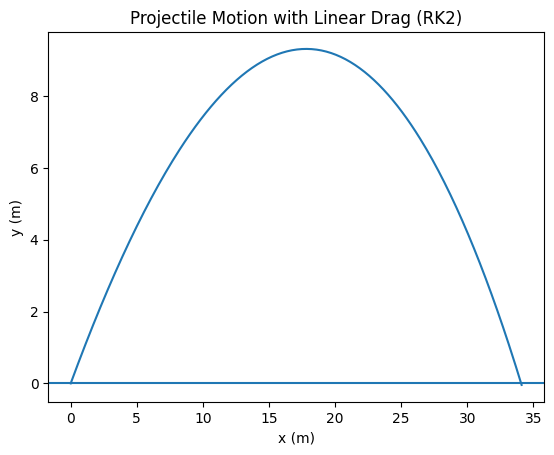

Flight time: 2.759999999999985
Range: 34.10899749857495
Maximum height: 9.308935592511286


In [16]:
plt.figure()
plt.plot(x_values, y_values)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Projectile Motion with Linear Drag (RK2)")
plt.axhline(0)
plt.show()

print("Flight time:", t_values[-1])
print("Range:", x_values[-1])
print("Maximum height:", max(y_values))


In [17]:
## The second order Runge-Katta method simulated projectile motion with linear drag. This can be shown as the projectile has a reduced range and a maximum height. trajectory decays due to the drag force being velocity-dependent.